In [24]:
import numpy as np
import matplotlib.pyplot as plt


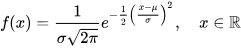

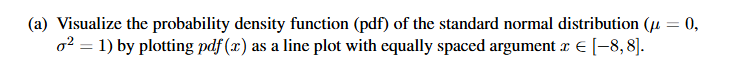

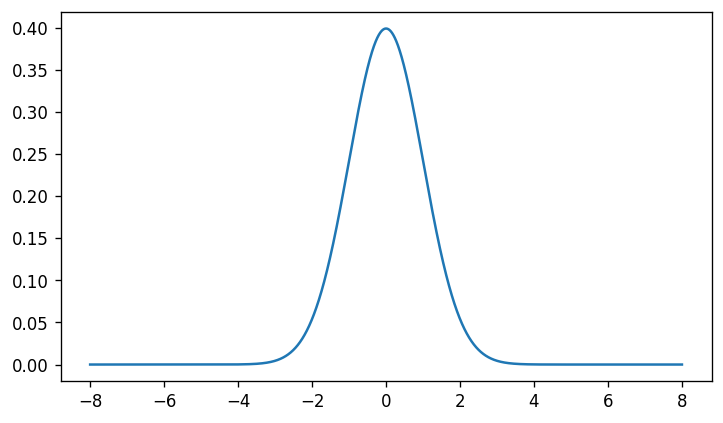

In [4]:
mu = 0
sig = 1
pi = np.pi
pdf = lambda x: np.exp(-0.5*(x-mu/sig)**2)/(sig*np.sqrt(2*pi))
x = np.linspace(-8, 8, 5000)
y = pdf(x)
plt.figure(figsize=(7,4), dpi = 120)
plt.plot(x,y)
plt.show()

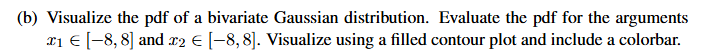

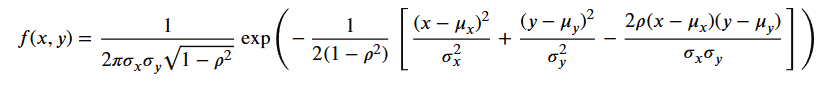

In [15]:
def bi_pdf(x,y, sig_x, sig_y, mu_x, mu_y, rho):
    fac = 1/(2*np.pi*sig_x*sig_y*np.sqrt(1-rho**2))
    fac_2 = 1/(2*(1-rho**2))
    sum1 = ((x - mu_x)**2)/(sig_x**2)
    sum2 = ((y - mu_y)**2)/(sig_y**2)
    sum3 = (2*rho*(x-mu_x)*(y-mu_y))/(sig_x*sig_y)
    return fac*np.exp(-fac_2*(sum1 + sum2 - sum3))

Z: (250, 250) 2


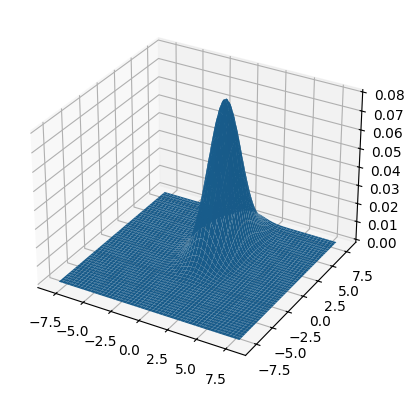

In [19]:
x = np.linspace(-8, 8, 250)
y = np.linspace(-8, 8, 250)
X, Y = np.meshgrid(x,y)
Z = bi_pdf(X,Y, 1, 2, 0.5, 3, 0)
print("Z:", Z.shape, Z.ndim)  # muss (250,250) und 2 sein
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X,Y,Z)
plt.show()

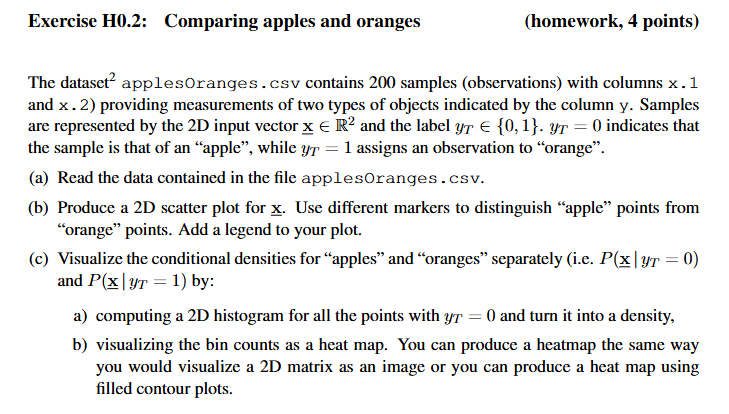

In [2]:
import os

In [13]:
import pandas as pd
cwd = os.getcwd()
path = os.path.join(cwd, "applesOranges.csv")
df = pd.read_csv(path)

In [22]:
mask = (df["y"]==1)
apples = df.loc[mask, ["x.1", "x.2"]]
print(apples)
mask = (df["y"]==0)
oranges = df.loc[mask, ["x.1", "x.2"]]

       x.1    x.2
100 -0.283  0.940
101 -0.440  1.068
102  0.783  0.268
103  1.326  0.109
104  0.489 -0.663
..     ...    ...
195  0.784  0.616
196  0.411 -0.005
197  0.930  0.225
198  1.288  0.184
199  0.110  1.114

[100 rows x 2 columns]


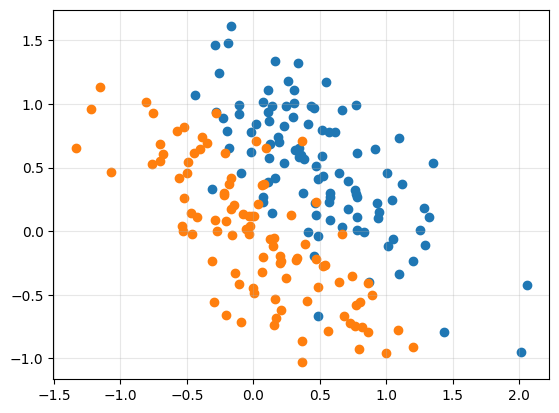

In [29]:
fig = plt.figure()

plt.scatter(apples["x.1"], apples["x.2"], label="Apples")
plt.scatter(oranges["x.1"],oranges["x.2"], label="Oranges" )
plt.grid(True, alpha=0.3)
plt.show()

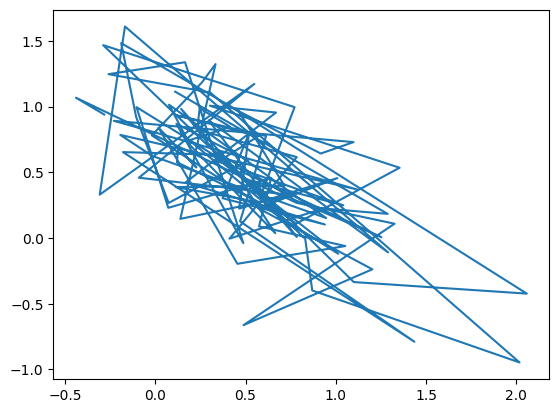

In [33]:
plt.plot(apples["x.1"],apples["x.2"] )
plt.show()

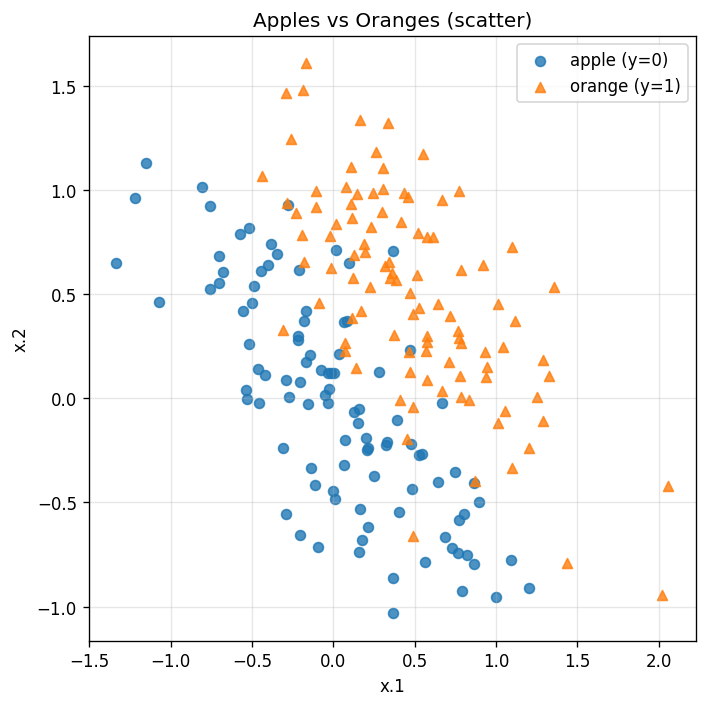

In [34]:
x1 = df["x.1"].to_numpy()
x2 = df["x.2"].to_numpy()
y  = df["y"].to_numpy()

mask_a = (y == 0)  # apples
mask_o = (y == 1)  # oranges

plt.figure(figsize=(6,6), dpi=120)
plt.scatter(x1[mask_a], x2[mask_a], marker="o", s=35, label="apple (y=0)", alpha=0.8)
plt.scatter(x1[mask_o], x2[mask_o], marker="^", s=35, label="orange (y=1)", alpha=0.8)

plt.xlabel("x.1")
plt.ylabel("x.2")
plt.title("Apples vs Oranges (scatter)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def hist2d_density(x, y, xedges, yedges):
    # counts: absolute Häufigkeiten pro Bin
    counts, _, _ = np.histogram2d(x, y, bins=[xedges, yedges]) # bins sind Rechtecke in den die Punkte gezählt werden
    dx = np.diff(xedges)[0]
    dy = np.diff(yedges)[0] # Gibt die Breite eines Bins an
    N  = len(x)
    # density so dass Sum(density)*dx*dy ≈ 1
    density = counts / (N * dx * dy) # Counts/N ist die Wahrscheinlichkeit für den bin. Dann Wahrscheinlichkeit/Fläche
    return density

# gemeinsame Achsen/Edges (mit leichtem padding)
pad = 0.2
xmin, xmax = x1.min()-pad, x1.max()+pad
ymin, ymax = x2.min()-pad, x2.max()+pad

bins = 35
xedges = np.linspace(xmin, xmax, bins+1)
yedges = np.linspace(ymin, ymax, bins+1)

# Densities getrennt nach Klasse
dens_a = hist2d_density(x1[mask_a], x2[mask_a], xedges, yedges)
dens_o = hist2d_density(x1[mask_o], x2[mask_o], xedges, yedges)

# Bin-Zentren (für contourf)
xc = 0.5*(xedges[:-1] + xedges[1:])
yc = 0.5*(yedges[:-1] + yedges[1:])
Xc, Yc = np.meshgrid(xc, yc, indexing="xy")

print("check norm apples ~", dens_a.sum() * (xedges[1]-xedges[0]) * (yedges[1]-yedges[0]))
print("check norm oranges ~", dens_o.sum() * (xedges[1]-xedges[0]) * (yedges[1]-yedges[0]))


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
check norm apples ~ 1.0000000000000002
check norm oranges ~ 1.0


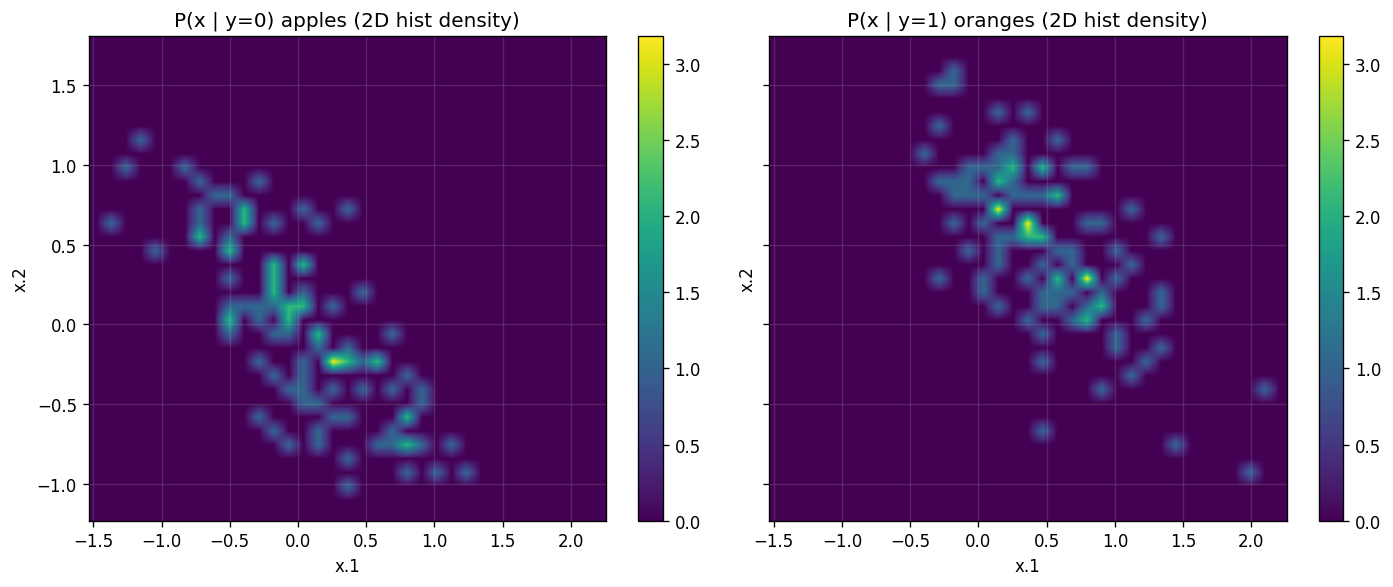

In [36]:
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

fig, ax = plt.subplots(1, 2, figsize=(12,5), dpi=120, sharex=True, sharey=True)

im0 = ax[0].imshow(dens_a.T, origin="lower", extent=extent, aspect="auto", interpolation="bilinear")
ax[0].set_title("P(x | y=0) apples (2D hist density)")
ax[0].set_xlabel("x.1"); ax[0].set_ylabel("x.2")
fig.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(dens_o.T, origin="lower", extent=extent, aspect="auto", interpolation="bilinear")
ax[1].set_title("P(x | y=1) oranges (2D hist density)")
ax[1].set_xlabel("x.1"); ax[1].set_ylabel("x.2")
fig.colorbar(im1, ax=ax[1])

for a in ax:
    a.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


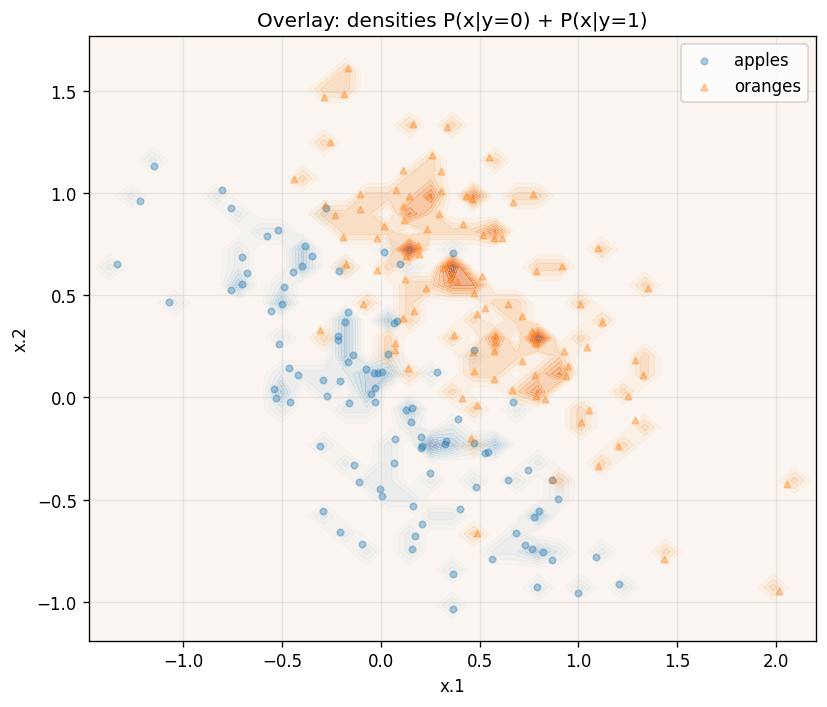

In [37]:
plt.figure(figsize=(7,6), dpi=120)

# Level-Set: nimm Quantile/Skalierung; simpel: wenige Level reichen oft
levels_a = np.linspace(dens_a.min(), dens_a.max(), 12)
levels_o = np.linspace(dens_o.min(), dens_o.max(), 12)

# contourf erwartet Z auf (len(yc), len(xc)) -> wir nutzen dens.T bzw bauen passend:
plt.contourf(Xc, Yc, dens_a.T, levels=levels_a, cmap="Blues", alpha=0.45)
plt.contourf(Xc, Yc, dens_o.T, levels=levels_o, cmap="Oranges", alpha=0.45)

# optional: Punkte als “ground truth”
plt.scatter(x1[mask_a], x2[mask_a], marker="o", s=15, alpha=0.35, label="apples")
plt.scatter(x1[mask_o], x2[mask_o], marker="^", s=15, alpha=0.35, label="oranges")

plt.xlabel("x.1")
plt.ylabel("x.2")
plt.title("Overlay: densities P(x|y=0) + P(x|y=1)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


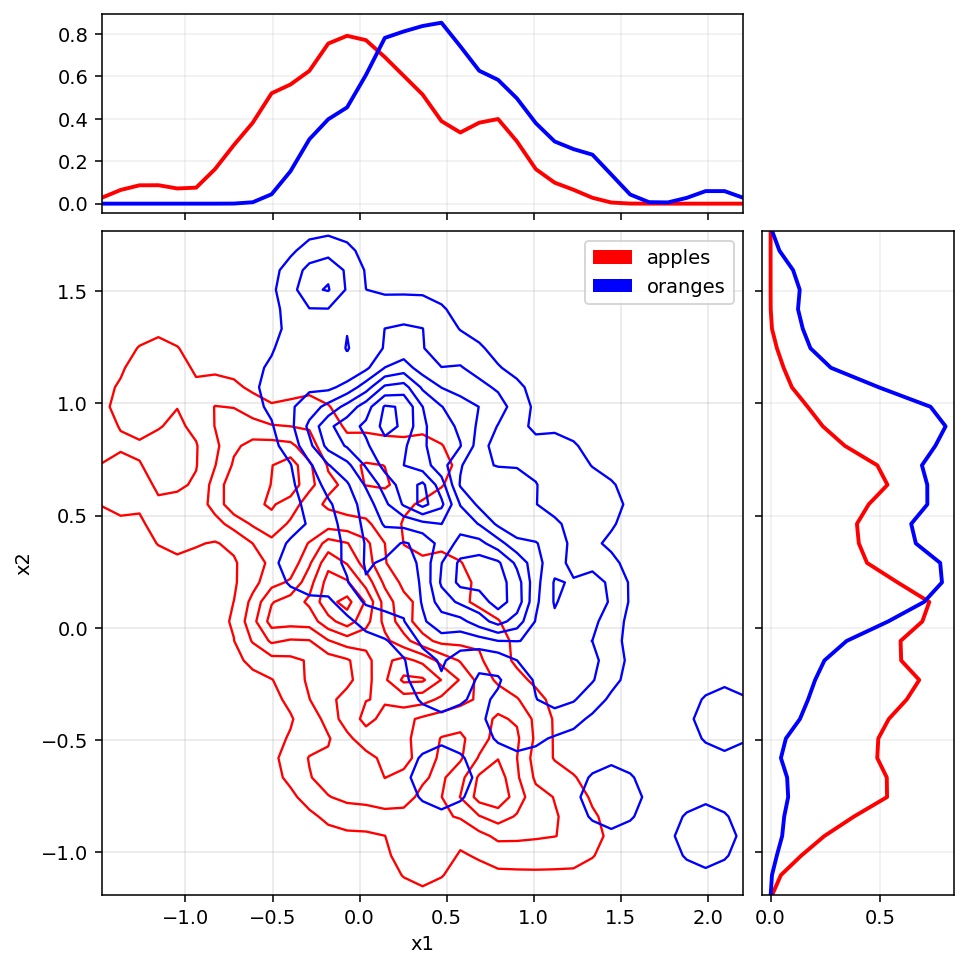

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# --- data ---
# df = pd.read_csv("applesOranges.csv")   # falls noch nicht geladen
x1 = df["x.1"].to_numpy()
x2 = df["x.2"].to_numpy()
y  = df["y"].to_numpy()

mask_a = (y == 0)   # apples
mask_o = (y == 1)   # oranges

# --- small gaussian smoothing (numpy-only) ---
def gaussian_kernel1d(sigma, radius=None):
    sigma = float(sigma)
    if sigma <= 0:
        return np.array([1.0])
    if radius is None:
        radius = int(3*sigma + 0.5)
    xs = np.arange(-radius, radius+1)
    k = np.exp(-(xs*xs)/(2*sigma*sigma))
    return k / k.sum()

def convolve1d_same(arr, k, axis):
    pad = len(k)//2
    pad_width = [(0,0)] * arr.ndim
    pad_width[axis] = (pad, pad)
    arrp = np.pad(arr, pad_width, mode="edge")
    return np.apply_along_axis(lambda m: np.convolve(m, k, mode="valid"), axis, arrp)

def smooth2d(Z, sigma_bins=1.0):
    k = gaussian_kernel1d(sigma_bins)
    Z = convolve1d_same(Z, k, axis=0)
    Z = convolve1d_same(Z, k, axis=1)
    return Z

def smooth1d(v, sigma_bins=1.0):
    k = gaussian_kernel1d(sigma_bins)
    pad = len(k)//2
    vp = np.pad(v, (pad, pad), mode="edge")
    return np.convolve(vp, k, mode="valid")

# --- binning (shared grid for fair comparison) ---
bins = 35          # mehr = feiner, weniger = glatter
sigma_bins = 1.0   # größer = glatter (in "bins" gemessen)

pad = 0.2
xmin, xmax = x1.min()-pad, x1.max()+pad
ymin, ymax = x2.min()-pad, x2.max()+pad

xedges = np.linspace(xmin, xmax, bins+1)
yedges = np.linspace(ymin, ymax, bins+1)
dx = xedges[1] - xedges[0]
dy = yedges[1] - yedges[0]

def hist2d_density(x, y):
    counts, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
    return counts / (len(x) * dx * dy)   # so dass sum(dens)*dx*dy ~ 1

dens_a = smooth2d(hist2d_density(x1[mask_a], x2[mask_a]), sigma_bins)
dens_o = smooth2d(hist2d_density(x1[mask_o], x2[mask_o]), sigma_bins)

# bin centers for contour plotting
xc = 0.5*(xedges[:-1] + xedges[1:])
yc = 0.5*(yedges[:-1] + yedges[1:])
Xc, Yc = np.meshgrid(xc, yc)  # shape (bins,bins)

# 1D marginals (density=True) + smoothing
hx_a, _ = np.histogram(x1[mask_a], bins=xedges, density=True)
hx_o, _ = np.histogram(x1[mask_o], bins=xedges, density=True)
hy_a, _ = np.histogram(x2[mask_a], bins=yedges, density=True)
hy_o, _ = np.histogram(x2[mask_o], bins=yedges, density=True)

hx_a = smooth1d(hx_a, sigma_bins)
hx_o = smooth1d(hx_o, sigma_bins)
hy_a = smooth1d(hy_a, sigma_bins)
hy_o = smooth1d(hy_o, sigma_bins)

# --- layout like your solution screenshot ---
fig = plt.figure(figsize=(6.8, 6.8), dpi=140, constrained_layout=True)
gs = GridSpec(2, 2, figure=fig, width_ratios=[4, 1.2], height_ratios=[1.2, 4])

ax_main  = fig.add_subplot(gs[1,0])
ax_top   = fig.add_subplot(gs[0,0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1,1], sharey=ax_main)
ax_corner = fig.add_subplot(gs[0,1]); ax_corner.axis("off")

# contours (transpose because histogram2d is (xbin,ybin) but meshgrid is (y,x))
levels_a = np.linspace(dens_a.max()*0.05, dens_a.max()*0.95, 7)
levels_o = np.linspace(dens_o.max()*0.05, dens_o.max()*0.95, 7)
ax_main.contour(Xc, Yc, dens_a.T, levels=levels_a, colors="red",  linewidths=1.2)
ax_main.contour(Xc, Yc, dens_o.T, levels=levels_o, colors="blue", linewidths=1.2)

ax_main.set_xlabel("x1")
ax_main.set_ylabel("x2")
ax_main.grid(True, alpha=0.3)
ax_main.legend(handles=[
    Patch(facecolor="red",  label="apples"),
    Patch(facecolor="blue", label="oranges"),
], loc="upper right")

# top marginal p(x1 | class)
ax_top.plot(xc, hx_a, color="red",  linewidth=2)
ax_top.plot(xc, hx_o, color="blue", linewidth=2)
ax_top.grid(True, alpha=0.2)
ax_top.tick_params(axis="x", labelbottom=False)

# right marginal p(x2 | class)
ax_right.plot(hy_a, yc, color="red",  linewidth=2)
ax_right.plot(hy_o, yc, color="blue", linewidth=2)
ax_right.grid(True, alpha=0.2)
ax_right.tick_params(axis="y", labelleft=False)

plt.show()


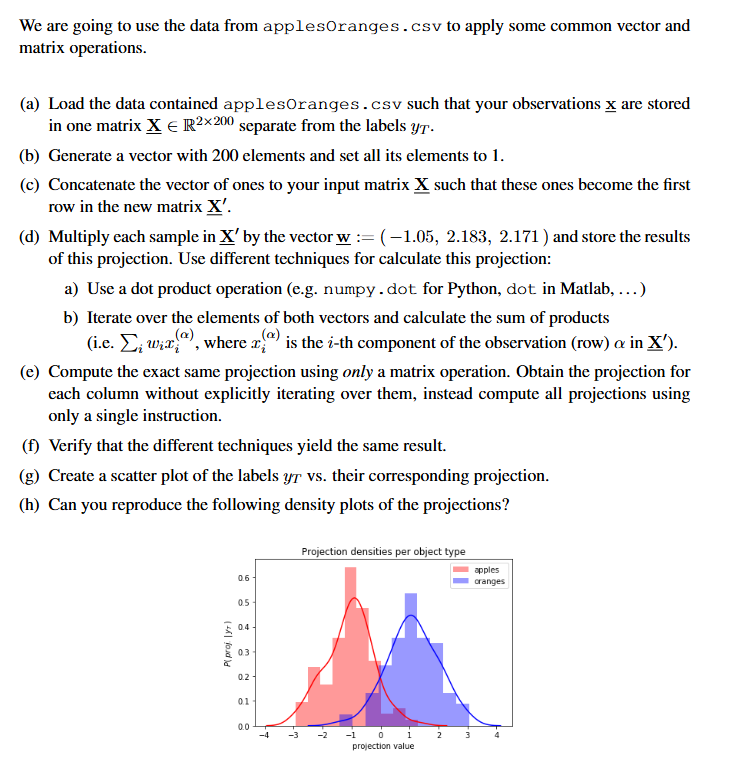

In [41]:
clear

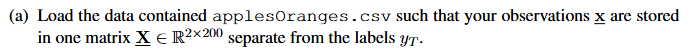

In [ ]:
# a)
import pandas as pd
cwd = os.getcwd()
path = os.path.join(cwd, "applesOranges.csv")
df = pd.read_csv(path)
x1 = df["x.1"].to_numpy()
x2 = df["x.2"].to_numpy()
y  = df["y"].to_numpy()

mask_a = (y == 0)   # apples
mask_o = (y == 1)   # oranges

X = df[["x.1", "x.2"]].to_numpy()
# x_o = x1[mask_o]
# y_o = y[mask_o]
# x_a = x1[mask_a]
# y_a = y[mask_a]
# print(X)

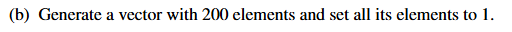

In [ ]:
# b)
vec_1 = np.ones(200)

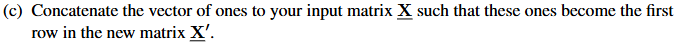

In [54]:
# c)
X_dash = A = np.column_stack([vec_1, X])
print(X_dash)

[[ 1.000e+00  3.650e-01  7.080e-01]
 [ 1.000e+00  5.430e-01 -2.680e-01]
 [ 1.000e+00 -4.010e-01  6.430e-01]
 [ 1.000e+00  8.660e-01 -7.960e-01]
 [ 1.000e+00 -3.860e-01  7.420e-01]
 [ 1.000e+00 -4.430e-01  6.150e-01]
 [ 1.000e+00 -5.190e-01  8.180e-01]
 [ 1.000e+00  3.320e-01 -2.110e-01]
 [ 1.000e+00  2.110e-01 -2.370e-01]
 [ 1.000e+00 -2.080e-01 -6.560e-01]
 [ 1.000e+00 -2.800e-02  4.400e-02]
 [ 1.000e+00 -2.710e-01  5.000e-03]
 [ 1.000e+00  1.590e-01 -7.390e-01]
 [ 1.000e+00  1.620e-01 -5.300e-01]
 [ 1.000e+00 -5.180e-01  2.630e-01]
 [ 1.000e+00  7.450e-01 -3.550e-01]
 [ 1.000e+00 -1.151e+00  1.133e+00]
 [ 1.000e+00  6.860e-01 -6.640e-01]
 [ 1.000e+00 -1.221e+00  9.620e-01]
 [ 1.000e+00  1.280e-01 -6.300e-02]
 [ 1.000e+00  1.001e+00 -9.560e-01]
 [ 1.000e+00 -8.070e-01  1.015e+00]
 [ 1.000e+00 -1.335e+00  6.510e-01]
 [ 1.000e+00  6.690e-01 -2.000e-02]
 [ 1.000e+00 -2.070e-01  8.100e-02]
 [ 1.000e+00  7.280e-01 -7.200e-01]
 [ 1.000e+00  8.220e-01 -7.530e-01]
 [ 1.000e+00 -1.110e-01 -4.1

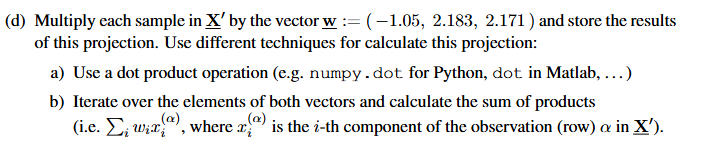

In [69]:
w = np.array([-1.05, 2.183, 2.171])
sum_1 = 0
projection_1 = np.zeros(len(X_dash))
for i, row in enumerate(X_dash):
    projection_1[i] += np.dot(row ,w)
    sum_1 += (np.dot(row ,w))
print(projection_1)

[ 1.283863 -0.446459 -0.52943  -0.887638 -0.281756 -0.681904 -0.407099
 -0.783325 -1.103914 -2.92824  -1.0156   -1.630738 -2.307272 -1.846984
 -1.609821 -0.19437  -1.10289  -0.994006 -1.626941 -0.907349 -0.940293
 -0.608116 -2.550984  0.367007 -1.32603  -1.023896 -0.890337 -2.191107
 -0.059028 -1.928894 -0.939984 -2.378478 -0.514719 -1.379732 -1.165447
 -1.138734  0.353448 -0.912772 -0.918493 -0.506806 -2.807467 -2.141968
 -2.065477 -0.945159 -1.496376 -0.359568 -0.490059 -0.833366 -1.329227
 -1.21446  -0.911501 -0.815676 -0.506334 -2.128961 -1.756813 -1.531731
 -1.351952 -2.236879 -0.596672 -1.097514 -0.495049 -0.399437 -0.626051
 -0.694368 -1.455714 -0.17519  -0.974362 -0.422231 -0.81799  -2.206978
 -1.124426 -1.023683  0.537217 -0.507095 -0.160836 -0.85936  -2.892353
 -1.036795 -1.362154  0.488402 -0.168947  0.57506  -1.596276 -0.302998
 -0.036594 -2.081141 -2.097588 -1.314057 -0.990887 -2.493677 -1.331378
 -1.725879 -1.149377 -0.774235 -0.109153 -2.14645  -1.571488 -0.874606
 -0.63

In [ ]:
# d)
# Ich nutze das Skalarprodukt mit einen 1-Vektor um die Summe der Elemente zu bekommen.
projection_2 = X_dash@w
sum_2 = np.dot(projection_2, vec_1)
print(projection_2)


[ 1.283863 -0.446459 -0.52943  -0.887638 -0.281756 -0.681904 -0.407099
 -0.783325 -1.103914 -2.92824  -1.0156   -1.630738 -2.307272 -1.846984
 -1.609821 -0.19437  -1.10289  -0.994006 -1.626941 -0.907349 -0.940293
 -0.608116 -2.550984  0.367007 -1.32603  -1.023896 -0.890337 -2.191107
 -0.059028 -1.928894 -0.939984 -2.378478 -0.514719 -1.379732 -1.165447
 -1.138734  0.353448 -0.912772 -0.918493 -0.506806 -2.807467 -2.141968
 -2.065477 -0.945159 -1.496376 -0.359568 -0.490059 -0.833366 -1.329227
 -1.21446  -0.911501 -0.815676 -0.506334 -2.128961 -1.756813 -1.531731
 -1.351952 -2.236879 -0.596672 -1.097514 -0.495049 -0.399437 -0.626051
 -0.694368 -1.455714 -0.17519  -0.974362 -0.422231 -0.81799  -2.206978
 -1.124426 -1.023683  0.537217 -0.507095 -0.160836 -0.85936  -2.892353
 -1.036795 -1.362154  0.488402 -0.168947  0.57506  -1.596276 -0.302998
 -0.036594 -2.081141 -2.097588 -1.314057 -0.990887 -2.493677 -1.331378
 -1.725879 -1.149377 -0.774235 -0.109153 -2.14645  -1.571488 -0.874606
 -0.63

In [74]:
# f)
print(projection_1 == projection_2)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  T

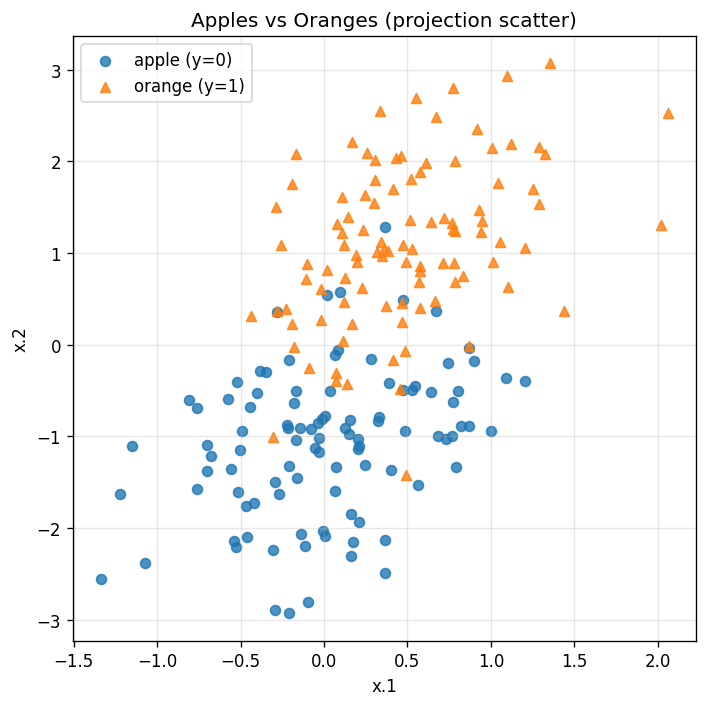

In [78]:
mask_a = (y == 0)  # apples
mask_o = (y == 1)  # oranges

plt.figure(figsize=(6,6), dpi=120)
plt.scatter(x1[mask_a], projection_1[mask_a], marker="o", s=35, label="apple (y=0)", alpha=0.8)
plt.scatter(x1[mask_o], projection_1[mask_o], marker="^", s=35, label="orange (y=1)", alpha=0.8)

plt.xlabel("x.1")
plt.ylabel("x.2")
plt.title("Apples vs Oranges (projection scatter)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

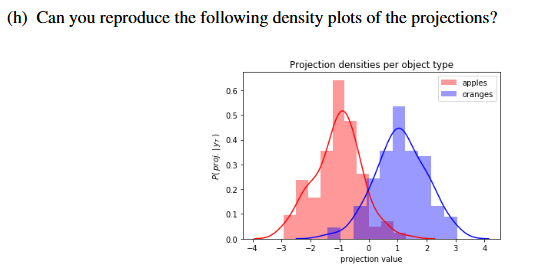

In [80]:
import matplotlib.pyplot as plt

<class 'numpy.ndarray'>


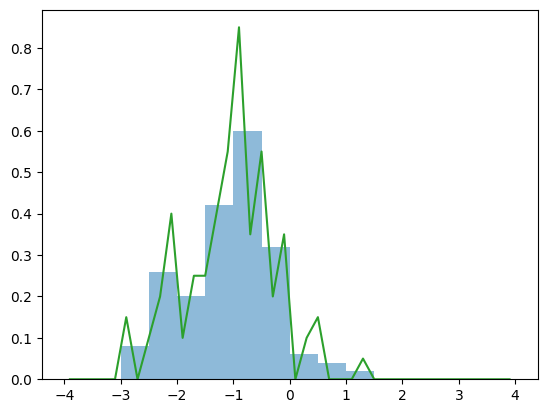

[0.   0.   0.   0.   0.   0.15 0.   0.1  0.2  0.4  0.1  0.25 0.25 0.4
 0.55 0.85 0.35 0.55 0.2  0.35 0.   0.1  0.15 0.   0.   0.   0.05 0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]


In [102]:
print(type(projection_1))
x_bins = np.arange(-4, 4.0001, 0.5)
x_bins_2 = np.arange(-4, 4.0001, 0.2)
plt.hist(projection_1[mask_a],density=True, bins=x_bins, alpha= 0.5)
counts, edges, patches = plt.hist(projection_1[mask_a], density=True, bins=x_bins_2, alpha= 0)
x_mids = 0.5 * (edges[:-1] + edges[1:])
plt.plot(x_mids, counts)
plt.show()
print(counts)

In [103]:
clear

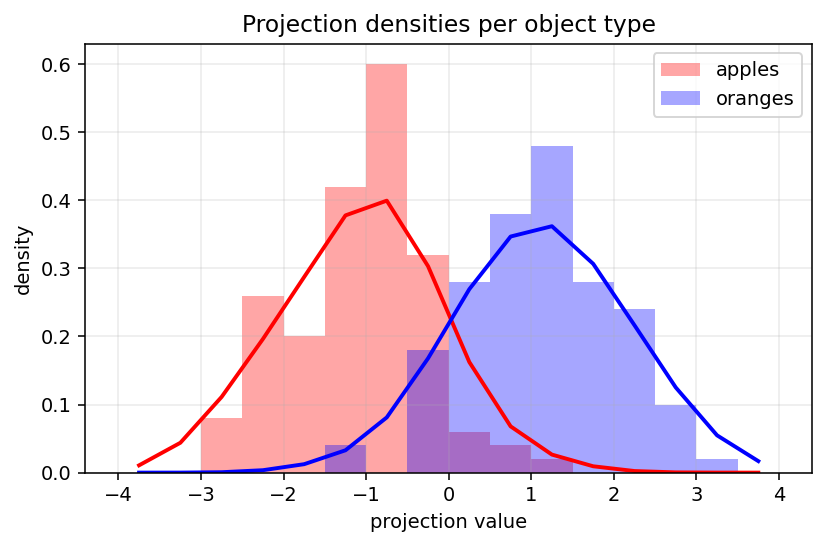

In [104]:
import numpy as np
import matplotlib.pyplot as plt

def smooth_hist_density(vals, bins, sigma_bins=1.2):
    counts, edges = np.histogram(vals, bins=bins, density=True)
    mids = 0.5*(edges[:-1] + edges[1:])

    r = int(3*sigma_bins + 0.5)
    t = np.arange(-r, r+1)
    k = np.exp(-(t**2)/(2*sigma_bins**2))
    k /= k.sum()

    smooth = np.convolve(counts, k, mode="same")
    return mids, smooth

vals_a = projection_1[mask_a]
vals_o = projection_1[mask_o]

bins = np.arange(-4, 4.0001, 0.5)

plt.figure(figsize=(6,4), dpi=140)
plt.hist(vals_a, bins=bins, density=True, alpha=0.35, color="red",  label="apples")
plt.hist(vals_o, bins=bins, density=True, alpha=0.35, color="blue", label="oranges")

m_a, s_a = smooth_hist_density(vals_a, bins, sigma_bins=1.2)
m_o, s_o = smooth_hist_density(vals_o, bins, sigma_bins=1.2)

plt.plot(m_a, s_a, color="red",  linewidth=2)
plt.plot(m_o, s_o, color="blue", linewidth=2)

plt.title("Projection densities per object type")
plt.xlabel("projection value")
plt.ylabel("density")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


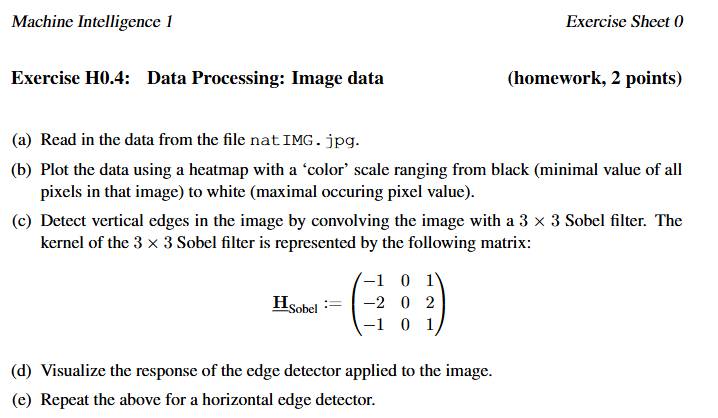

In [ ]:
from PIL import Image
import numpy as np
img = Image.open("natIMG.jpg")          # path to your jpg
arr = np.array(img)                    # shape: (H, W, 3) for RGB, dtype: uint8
print(arr.shape, arr.dtype)

(256, 512) uint8


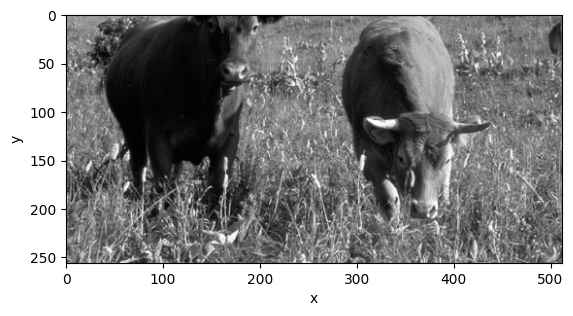

In [113]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
im = ax.imshow(arr, origin="upper", cmap="grey")
# fig.colorbar(im, ax=ax, label="value")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [116]:
H_Sobel = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

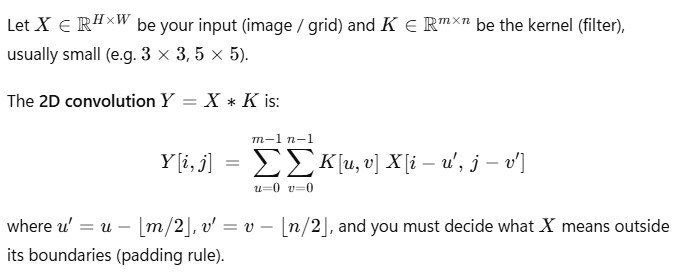

In [121]:
np.zeros((3,2))

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [ ]:
def convolute_2D(X,K): # doenst work
    Y = np.zeros(X.shape)
    m, n = K.shape
    for i in range(len(Y)):
        for j in range(len(Y[0])):
            sum = 0
            for u in range(m - 1):
                for v in range(n - 1):
                    u_dash = u - m/2
                    v_dash = v - n/2
                    sum += K[u,v]*X[i - u_dash, j - v_dash]
            Y[i, j] += sum
    return Y

In [128]:
def convolve2d_same(X, K, pad_mode="constant", pad_value=0.0, flip_kernel=True):
    X = np.asarray(X, dtype=float)
    K = np.asarray(K, dtype=float)

    # True convolution flips the kernel; correlation does not
    if flip_kernel:
        K = K[::-1, ::-1]

    m, n = K.shape
    ph, pw = m // 2, n // 2  # kernel "radius" (works best with odd m,n)

    # Pad input so output has same shape as X
    if pad_mode == "constant":
        Xp = np.pad(X, ((ph, ph), (pw, pw)), mode=pad_mode, constant_values=pad_value)
    else:
        Xp = np.pad(X, ((ph, ph), (pw, pw)), mode=pad_mode)

    Y = np.zeros_like(X, dtype=float)

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            patch = Xp[i:i+m, j:j+n]      # m×n neighborhood
            Y[i, j] = np.sum(patch * K)   # weighted sum

    return Y

In [134]:
Y = convolve2d_same(arr, H_Sobel)

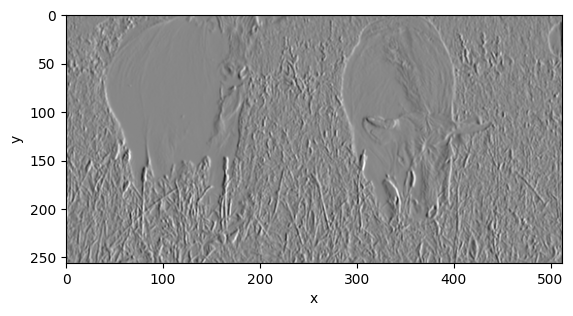

In [135]:
fig, ax = plt.subplots()
im = ax.imshow(Y, origin="upper", cmap="grey")
# fig.colorbar(im, ax=ax, label="value")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

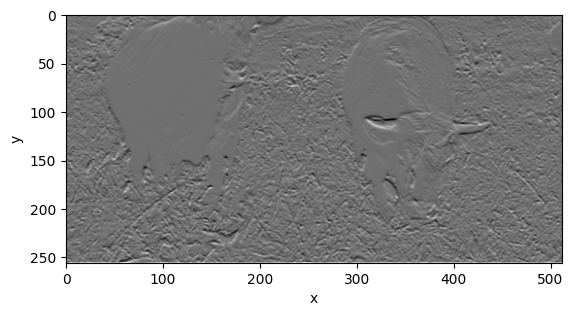

In [132]:
H_Sobel_horizontal = np.array([[-1, -2, -1],
                               [ 0,  0,  0],
                               [ 1,  2,  1]])
Y = convolve2d_same(arr, H_Sobel_horizontal)
fig, ax = plt.subplots()
im = ax.imshow(Y, origin="upper", cmap="grey")
# fig.colorbar(im, ax=ax, label="value")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()